# Unit 6 — Training a U-Net for nuclei segmentation

We use [`segmentation_models_pytorch`](https://github.com/qubvel-org/segmentation_models.pytorch)
to assemble a **U-Net** with an **EfficientNet-B0** encoder pretrained on ImageNet.

Loss = **BCE + Dice**, optimizer = Adam, mild augmentations (flips, rotations).
We monitor validation **Dice** and keep the best checkpoint.

In [1]:
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"smp version: {smp.__version__}")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

Device: cuda
smp version: 0.5.0


## 1. Dataset

Pair each fluorescence image with its mask. Apply augmentations for train, plain resize/normalise
for val/test. The EfficientNet-B0 encoder expects ImageNet-normalised RGB.

In [2]:
ROOT = "datasets/bbbc039_seg"
IMG_SIZE = 512

# ImageNet stats for the pretrained encoder
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class NucleiDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        fname = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  fname)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, fname)).convert("L")) // 255
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0).float()

# Use the test split as our validation set (no separate val needed for this size).
train_ds = NucleiDataset("train", train_tf)
val_ds   = NucleiDataset("test",  eval_tf)

print(f"train: {len(train_ds)}   val: {len(val_ds)}")
x, y = train_ds[0]
print(f"image tensor: {tuple(x.shape)} dtype {x.dtype}, mask tensor: {tuple(y.shape)} dtype {y.dtype}")
print(f"mask unique values: {torch.unique(y).tolist()}")

train: 160   val: 40
image tensor: (3, 512, 512) dtype torch.float32, mask tensor: (1, 512, 512) dtype torch.float32
mask unique values: [0.0, 1.0]


Light data loaders. Batch size 4 fits ~8 GB at 512×512.

In [3]:
BATCH = 4
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

## 2. Model — `smp.Unet(efficientnet-b0)`

The U-Net decoder is upsampling with skip connections from the encoder feature pyramid.
EfficientNet-B0 is a small, fast encoder (~5M params) with ImageNet pretraining.

In [4]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,            # binary mask, single logit channel
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params/1e6:.2f} M")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model parameters: 6.25 M


## 3. Loss = BCE + Dice

* **BCE** drives pixel-wise calibration.
* **Dice** drives overlap (and is robust to the background imbalance we saw in EDA).
* `smp.losses.DiceLoss(mode='binary')` expects logits (no sigmoid).

In [5]:
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def combined_loss(logits, target):
    return 0.5 * bce_loss(logits, target) + 0.5 * dice_loss(logits, target)

@torch.no_grad()
def dice_iou(logits, target, thr=0.5):
    """Per-batch micro-averaged Dice and IoU."""
    pred = (torch.sigmoid(logits) > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, target.long(), mode="binary")
    dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item()
    iou  = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
    return dice, iou

## 4. Training loop

30 epochs is comfortable on a single GPU (~5–8 min). We save the best checkpoint by
validation Dice.

In [6]:
EPOCHS = 30
LR     = 1e-4
CKPT   = "checkpoints/unet_efficientnet-b0.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_dice = -1.0

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = combined_loss(logits, y)
        loss.backward()
        opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    # ---- val ----
    model.eval()
    v_losses, v_dices, v_ious = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            v_losses.append(combined_loss(logits, y).item())
            d, i = dice_iou(logits, y)
            v_dices.append(d); v_ious.append(i)

    tr = float(np.mean(tr_losses))
    vl = float(np.mean(v_losses))
    vd = float(np.mean(v_dices))
    vi = float(np.mean(v_ious))
    history["train_loss"].append(tr); history["val_loss"].append(vl)
    history["val_dice"].append(vd);   history["val_iou"].append(vi)

    flag = ""
    if vd > best_dice:
        best_dice = vd
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd}, CKPT)
        flag = "  ★ new best"
    print(f"epoch {epoch:02d}  train_loss={tr:.3f}  val_loss={vl:.3f}  "
          f"val_dice={vd:.3f}  val_iou={vi:.3f}{flag}")

print(f"\nBest val Dice = {best_dice:.4f}   → checkpoint at {CKPT}")

epoch 01  train_loss=0.581  val_loss=0.640  val_dice=0.470  val_iou=0.310  ★ new best


epoch 02  train_loss=0.407  val_loss=0.436  val_dice=0.897  val_iou=0.814  ★ new best


epoch 03  train_loss=0.331  val_loss=0.347  val_dice=0.922  val_iou=0.856  ★ new best


epoch 04  train_loss=0.278  val_loss=0.289  val_dice=0.939  val_iou=0.885  ★ new best


epoch 05  train_loss=0.239  val_loss=0.245  val_dice=0.946  val_iou=0.897  ★ new best


...

epoch 26  train_loss=0.086  val_loss=0.083  val_dice=0.964  val_iou=0.930


epoch 27  train_loss=0.083  val_loss=0.082  val_dice=0.964  val_iou=0.930  ★ new best


epoch 28  train_loss=0.084  val_loss=0.081  val_dice=0.964  val_iou=0.930


epoch 29  train_loss=0.083  val_loss=0.083  val_dice=0.964  val_iou=0.930


epoch 30  train_loss=0.084  val_loss=0.080  val_dice=0.964  val_iou=0.931  ★ new best

Best val Dice = 0.9640   → checkpoint at checkpoints/unet_efficientnet-b0.pt


## 5. Training curves

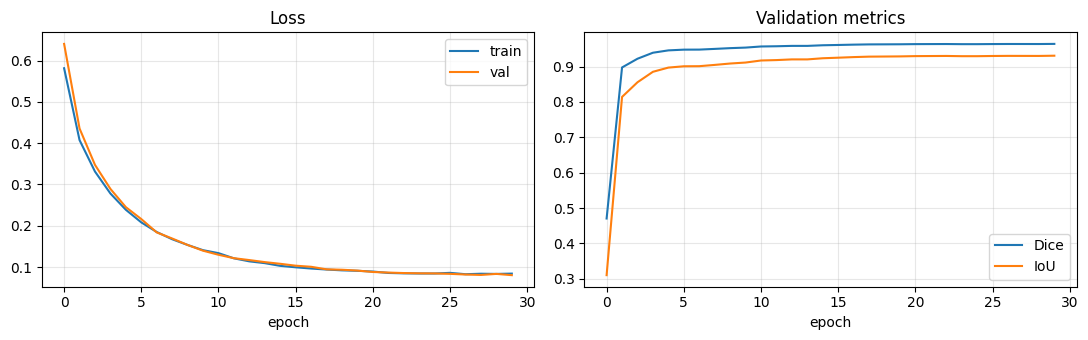

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"],   label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history["val_dice"], label="Dice")
ax[1].plot(history["val_iou"],  label="IoU")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Sanity-check

Load the best checkpoint and overlay predictions on the val set.

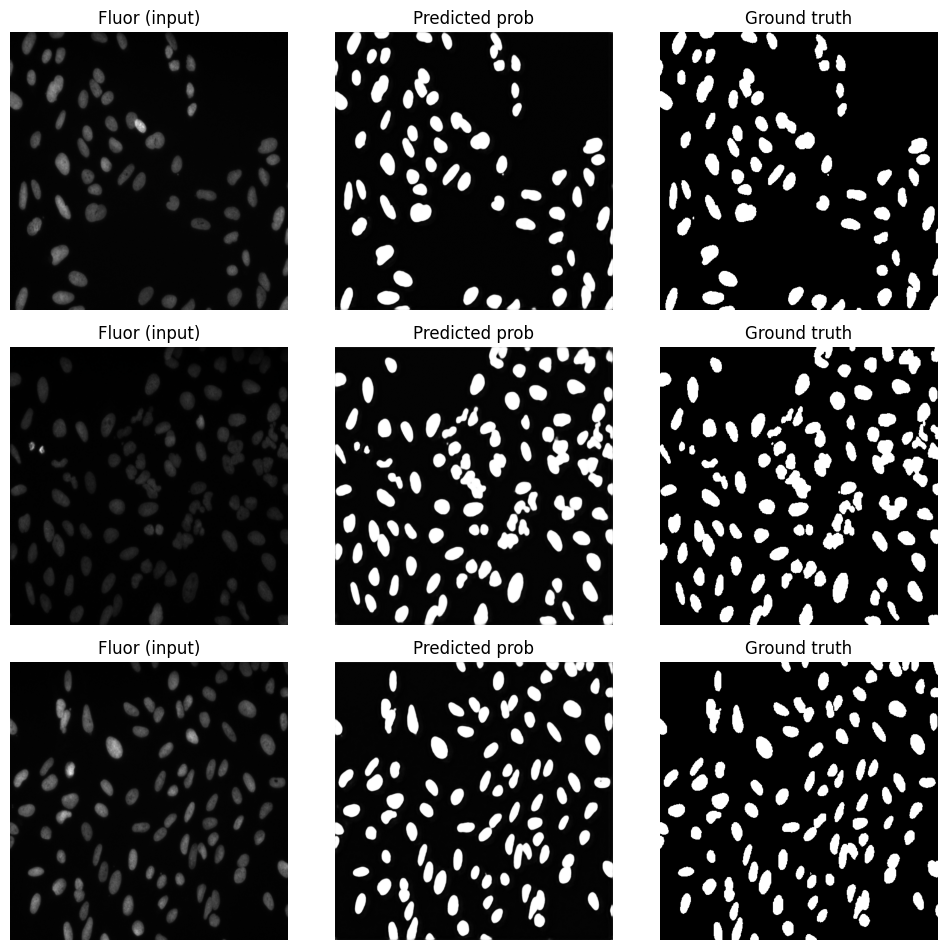

In [8]:
state = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(state["model"])
model.eval()

# Pull one batch from val and visualise
x, y = next(iter(val_loader))
with torch.no_grad():
    pred = torch.sigmoid(model(x.to(device))).cpu()

def denorm(t):
    arr = t.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)
    return np.clip(arr, 0, 1)

n = min(3, x.size(0))
fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
for i in range(n):
    axes[i, 0].imshow(denorm(x[i]));            axes[i, 0].set_title("Fluor (input)")
    axes[i, 1].imshow(pred[i, 0], cmap="gray"); axes[i, 1].set_title("Predicted prob")
    axes[i, 2].imshow(y[i, 0],    cmap="gray"); axes[i, 2].set_title("Ground truth")
    for ax in axes[i]: ax.axis("off")
plt.tight_layout(); plt.show()

## Summary

We trained a small U-Net (5M-param EfficientNet-B0 encoder) to segment nuclei from
fluorescence images. The combined BCE + Dice loss handles the strong background bias.
Next: a proper evaluation with Dice/IoU and a robustness probe under Gaussian noise.